# Étape 3 : Feature Engineering

## Objectif
Créer des **features** (variables) supplémentaires à partir des données existantes pour améliorer les performances du modèle ML.

## Pourquoi faire du Feature Engineering ?
Les modèles de Machine Learning apprennent mieux quand on leur fournit des informations **explicites** :
- Au lieu de juste la date → donner **l'heure**, le **jour de la semaine**, si c'est le **weekend**
- Au lieu de juste la température → donner des **catégories** (froid/doux/chaud)
- Au lieu de juste la pluie → indiquer si **il pleut ou non** (booléen)

## Plan
1. Charger le dataset fusionné
2. Créer des features temporelles
3. Créer des features météo enrichies
4. Encoder les variables catégorielles
5. Visualiser l'impact des nouvelles features
6. Sauvegarder le dataset final

---

## 3.1 Import et Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print("Bibliothèques importées!")

Bibliothèques importées!


In [2]:
# Charger le dataset fusionné de l'étape 2
df = pd.read_csv('../CSVs/data_merged.csv', sep=';')

# Convertir timestamp en datetime (si ce n'est pas déjà fait)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Dataset chargé!")
print(f"Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Période : {df['timestamp'].min()} → {df['timestamp'].max()}")
print("\n" + "="*80)
df.head()

Dataset chargé!
Dimensions : 696 lignes x 4 colonnes
Période : 2022-04-01 00:00:00+02:00 → 2022-04-29 23:00:00+02:00



,timestamp,nb_velos,temperature,precipitation
0,2022-04-01 00:00:00+02:00,3607,7.398026,0.1
1,2022-04-01 01:00:00+02:00,1762,6.958333,0.0
2,2022-04-01 02:00:00+02:00,1207,6.493590,1.0
3,2022-04-01 03:00:00+02:00,878,4.508224,18.8
4,2022-04-01 04:00:00+02:00,652,2.695724,36.7


In [3]:
# Vérifier les colonnes actuelles
print("Colonnes actuelles :")
print("="*80)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col} ({df[col].dtype})")

Colonnes actuelles :
1. timestamp (datetime64[ns, UTC+02:00])
2. nb_velos (int64)
3. temperature (float64)
4. precipitation (float64)


---
## 3.2 Features Temporelles

### Pourquoi ?
Le trafic vélo varie énormément selon :
- **L'heure** : Pics à 8h et 18h (trajets domicile-travail)
- **Le jour** : Moins de vélos le weekend
- **Le mois** : Plus de vélos en été qu'en hiver

### Features à créer :
1. `hour` : Heure de la journée (0-23)
2. `day_of_week` : Jour de la semaine (0=Lundi, 6=Dimanche)
3. `day_name` : Nom du jour (Lundi, Mardi...)
4. `is_weekend` : Booléen (1 si Samedi/Dimanche, 0 sinon)
5. `month` : Mois (1-12)
6. `is_rush_hour` : Booléen (1 si 7-9h ou 17-19h, 0 sinon)

In [4]:
print("Création des features temporelles...\n")

# 1. Heure de la journée (0-23)
df['hour'] = df['timestamp'].dt.hour
print("'hour' créée (0-23)")

# 2. Jour de la semaine (0=Lundi, 6=Dimanche)
df['day_of_week'] = df['timestamp'].dt.dayofweek
print("'day_of_week' créée (0=Lundi, 6=Dimanche)")

# 3. Nom du jour
df['day_name'] = df['timestamp'].dt.day_name()
print("'day_name' créée (Monday, Tuesday...)")

# 4. Weekend (1 si Samedi=5 ou Dimanche=6, 0 sinon)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
print("'is_weekend' créée (0 ou 1)")

# 5. Mois
df['month'] = df['timestamp'].dt.month
print("'month' créée (1-12)")

# 6. Heure de pointe (rush hour)
# Matin : 7-9h, Soir : 17-19h
df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) | 
                       (df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
print("'is_rush_hour' créée (1 si 7-9h ou 17-19h)")

print("\n" + "="*80)
print("Aperçu avec les nouvelles features :")
df[['timestamp', 'nb_velos', 'hour', 'day_of_week', 'day_name', 'is_weekend', 'is_rush_hour']].head(10)

Création des features temporelles...

'hour' créée (0-23)
'day_of_week' créée (0=Lundi, 6=Dimanche)
'day_name' créée (Monday, Tuesday...)
'is_weekend' créée (0 ou 1)
'month' créée (1-12)
'is_rush_hour' créée (1 si 7-9h ou 17-19h)

Aperçu avec les nouvelles features :


,timestamp,nb_velos,hour,day_of_week,day_name,is_weekend,is_rush_hour
0,2022-04-01 00:00:00+02:00,3607,0,4,Friday,0,0
1,2022-04-01 01:00:00+02:00,1762,1,4,Friday,0,0
2,2022-04-01 02:00:00+02:00,1207,2,4,Friday,0,0
3,2022-04-01 03:00:00+02:00,878,3,4,Friday,0,0
4,2022-04-01 04:00:00+02:00,652,4,4,Friday,0,0
5,2022-04-01 05:00:00+02:00,885,5,4,Friday,0,0
6,2022-04-01 06:00:00+02:00,2315,6,4,Friday,0,0
7,2022-04-01 07:00:00+02:00,9696,7,4,Friday,0,1
8,2022-04-01 08:00:00+02:00,21176,8,4,Friday,0,1
9,2022-04-01 09:00:00+02:00,11340,9,4,Friday,0,1


In [5]:
# Vérification : Distribution par jour de la semaine
print("Distribution du trafic vélo par jour de la semaine :")
print("="*80)

jour_mapping = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}

avg_by_day = df.groupby('day_of_week')['nb_velos'].mean().sort_index()
for day, avg in avg_by_day.items():
    print(f"{jour_mapping[day]:<10} : {avg:>8,.0f} vélos/heure en moyenne")

print("\nOn devrait voir moins de trafic le weekend!")

Distribution du trafic vélo par jour de la semaine :
Lundi      :    9,578 vélos/heure en moyenne
Mardi      :   12,094 vélos/heure en moyenne
Mercredi   :   12,257 vélos/heure en moyenne
Jeudi      :   12,507 vélos/heure en moyenne
Vendredi   :   10,823 vélos/heure en moyenne
Samedi     :    6,415 vélos/heure en moyenne
Dimanche   :    6,648 vélos/heure en moyenne

On devrait voir moins de trafic le weekend!


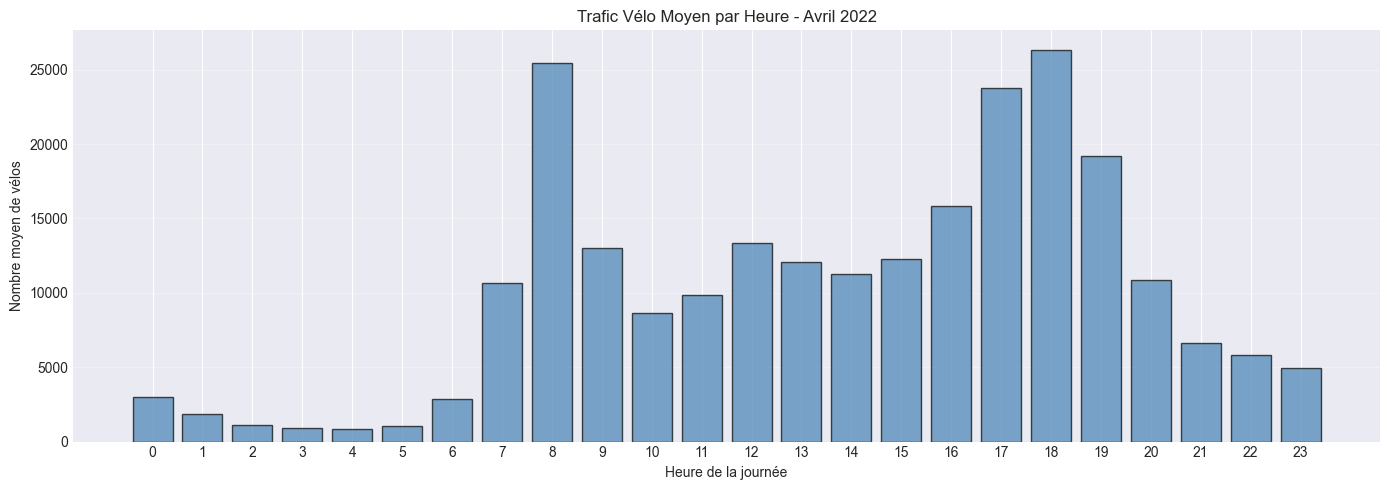

On devrait voir des pics à 8h et 18h (heures de pointe)


In [6]:
# Visualisation : Trafic moyen par heure
plt.figure(figsize=(14, 5))

avg_by_hour = df.groupby('hour')['nb_velos'].mean()

plt.bar(avg_by_hour.index, avg_by_hour.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre moyen de vélos')
plt.title('Trafic Vélo Moyen par Heure - Avril 2022')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("On devrait voir des pics à 8h et 18h (heures de pointe)")

---
## 3.3 Features Météo Enrichies

### Pourquoi ?
Au lieu de donner juste la température brute (ex: 12.5°C), on va créer des **catégories** plus faciles à interpréter :
- Froid (< 10°C)
- Doux (10-18°C)
- Chaud (> 18°C)

### Features à créer :
1. `is_raining` : Booléen (1 si précipitations > 0, 0 sinon)
2. `rain_intensity` : Catégorie (none/light/moderate/heavy)
3. `temp_category` : Catégorie (cold/mild/warm)

In [7]:
print("Création des features météo enrichies...\n")

# 1. Est-ce qu'il pleut ? (booléen)
df['is_raining'] = (df['precipitation'] > 0).astype(int)
print(f"'is_raining' créée")
print(f"   → {df['is_raining'].sum()} heures avec pluie sur {len(df)} ({df['is_raining'].sum()/len(df)*100:.1f}%)\n")

# 2. Intensité de la pluie
def classify_rain(precip):
    if precip == 0:
        return 'none'
    elif precip <= 0.2:
        return 'light'
    elif precip <= 0.5:
        return 'moderate'
    else:
        return 'heavy'

df['rain_intensity'] = df['precipitation'].apply(classify_rain)
print("'rain_intensity' créée (none/light/moderate/heavy)")
print(df['rain_intensity'].value_counts())

# 3. Catégorie de température
def classify_temp(temp):
    if temp < 10:
        return 'cold'
    elif temp <= 18:
        return 'mild'
    else:
        return 'warm'

df['temp_category'] = df['temperature'].apply(classify_temp)
print("\n'temp_category' créée (cold/mild/warm)")
print(df['temp_category'].value_counts())

print("\n" + "="*80)
print(" Aperçu avec features météo enrichies :")
df[['timestamp', 'nb_velos', 'temperature', 'temp_category', 'precipitation', 'is_raining', 'rain_intensity']].head(10)

Création des features météo enrichies...

'is_raining' créée
   → 116 heures avec pluie sur 696 (16.7%)

'rain_intensity' créée (none/light/moderate/heavy)
rain_intensity
none        580
heavy        78
light        27
moderate     11
Name: count, dtype: int64

'temp_category' créée (cold/mild/warm)
temp_category
mild    404
cold    178
warm    114
Name: count, dtype: int64

 Aperçu avec features météo enrichies :


,timestamp,nb_velos,temperature,temp_category,precipitation,is_raining,rain_intensity
0,2022-04-01 00:00:00+02:00,3607,7.398026,cold,0.1,1,light
1,2022-04-01 01:00:00+02:00,1762,6.958333,cold,0.0,0,none
2,2022-04-01 02:00:00+02:00,1207,6.493590,cold,1.0,1,heavy
3,2022-04-01 03:00:00+02:00,878,4.508224,cold,18.8,1,heavy
4,2022-04-01 04:00:00+02:00,652,2.695724,cold,36.7,1,heavy
5,2022-04-01 05:00:00+02:00,885,2.106250,cold,40.3,1,heavy
6,2022-04-01 06:00:00+02:00,2315,1.548077,cold,47.3,1,heavy
7,2022-04-01 07:00:00+02:00,9696,1.365809,cold,33.2,1,heavy
8,2022-04-01 08:00:00+02:00,21176,1.513514,cold,16.9,1,heavy
9,2022-04-01 09:00:00+02:00,11340,1.859797,cold,3.8,1,heavy


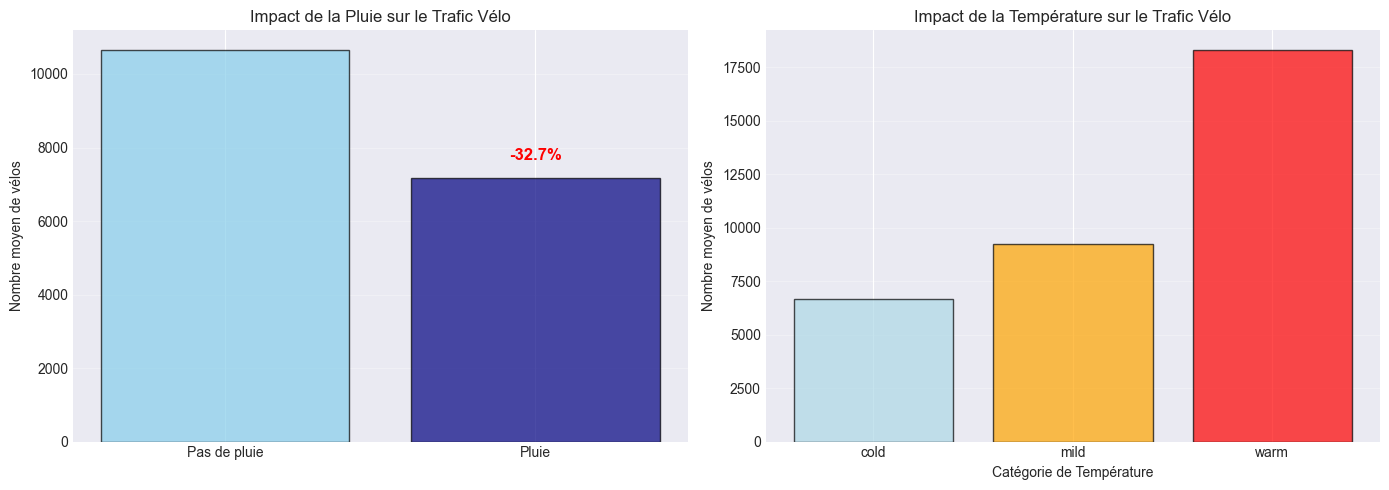


Insights :
   - La pluie réduit le trafic vélo de 32.7%
   - Trafic froid : 6672 vélos/h
   - Trafic doux : 9247 vélos/h
   - Trafic chaud : 18310 vélos/h


In [8]:
# Visualisation : Impact de la pluie sur le trafic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Comparaison Pluie vs Pas de Pluie
rain_comparison = df.groupby('is_raining')['nb_velos'].mean()
labels = ['Pas de pluie', 'Pluie']
axes[0].bar(labels, rain_comparison.values, color=['skyblue', 'navy'], edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Nombre moyen de vélos')
axes[0].set_title('Impact de la Pluie sur le Trafic Vélo')
axes[0].grid(True, alpha=0.3, axis='y')

# Calculer la baisse en %
baisse_pct = ((rain_comparison[0] - rain_comparison[1]) / rain_comparison[0]) * 100
axes[0].text(1, rain_comparison[1] + 500, f'-{baisse_pct:.1f}%', ha='center', fontsize=12, fontweight='bold', color='red')

# 2. Trafic par catégorie de température
temp_comparison = df.groupby('temp_category')['nb_velos'].mean().reindex(['cold', 'mild', 'warm'])
axes[1].bar(temp_comparison.index, temp_comparison.values, color=['lightblue', 'orange', 'red'], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Catégorie de Température')
axes[1].set_ylabel('Nombre moyen de vélos')
axes[1].set_title('Impact de la Température sur le Trafic Vélo')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nInsights :")
print(f"   - La pluie réduit le trafic vélo de {baisse_pct:.1f}%")
print(f"   - Trafic froid : {temp_comparison['cold']:.0f} vélos/h")
print(f"   - Trafic doux : {temp_comparison['mild']:.0f} vélos/h")
print(f"   - Trafic chaud : {temp_comparison['warm']:.0f} vélos/h")

---
## 3.4 Encodage des Variables Catégorielles

### Problème :
Les modèles de ML ne comprennent que les **nombres**. On ne peut pas utiliser directement :
- `day_name` = "Monday" (texte)
- `temp_category` = "cold" (texte)

### Solution : One-Hot Encoding
Transformer chaque catégorie en colonne binaire (0 ou 1).

**Exemple :**
```
temp_category = "cold" →  temp_cold=1, temp_mild=0, temp_warm=0
temp_category = "mild" →  temp_cold=0, temp_mild=1, temp_warm=0
```

In [9]:
print("Encodage des variables catégorielles...\n")

# Variables à encoder
categorical_vars = ['day_name', 'rain_intensity', 'temp_category']

print("Variables à encoder :")
for var in categorical_vars:
    print(f"  - {var} : {df[var].nunique()} catégories → {df[var].unique()}")

# One-Hot Encoding avec pd.get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_vars, prefix=categorical_vars, drop_first=False)

print("\nEncodage terminé!")
print(f"Avant : {df.shape[1]} colonnes")
print(f"Après : {df_encoded.shape[1]} colonnes")
print(f"\n→ {df_encoded.shape[1] - df.shape[1]} nouvelles colonnes créées")

Encodage des variables catégorielles...

Variables à encoder :
  - day_name : 7 catégories → ['Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday']
  - rain_intensity : 4 catégories → ['light' 'none' 'heavy' 'moderate']
  - temp_category : 3 catégories → ['cold' 'mild' 'warm']

Encodage terminé!
Avant : 13 colonnes
Après : 24 colonnes

→ 11 nouvelles colonnes créées


In [10]:
# Afficher toutes les colonnes créées
print("Toutes les colonnes du dataset final :")
print("="*80)
for i, col in enumerate(df_encoded.columns, 1):
    print(f"{i:2}. {col}")

Toutes les colonnes du dataset final :
 1. timestamp
 2. nb_velos
 3. temperature
 4. precipitation
 5. hour
 6. day_of_week
 7. is_weekend
 8. month
 9. is_rush_hour
10. is_raining
11. day_name_Friday
12. day_name_Monday
13. day_name_Saturday
14. day_name_Sunday
15. day_name_Thursday
16. day_name_Tuesday
17. day_name_Wednesday
18. rain_intensity_heavy
19. rain_intensity_light
20. rain_intensity_moderate
21. rain_intensity_none
22. temp_category_cold
23. temp_category_mild
24. temp_category_warm


In [11]:
# Aperçu du dataset avec encodage
print("Aperçu du dataset encodé :")
print("="*80)
df_encoded.head()

Aperçu du dataset encodé :


,timestamp,nb_velos,temperature,precipitation,hour,day_of_week,is_weekend,month,is_rush_hour,is_raining,...,day_name_Thursday,day_name_Tuesday,day_name_Wednesday,rain_intensity_heavy,rain_intensity_light,rain_intensity_moderate,rain_intensity_none,temp_category_cold,temp_category_mild,temp_category_warm
0,2022-04-01 00:00:00+02:00,3607,7.398026,0.1,0,4,0,4,0,1,...,False,False,False,False,True,False,False,True,False,False
1,2022-04-01 01:00:00+02:00,1762,6.958333,0.0,1,4,0,4,0,0,...,False,False,False,False,False,False,True,True,False,False
2,2022-04-01 02:00:00+02:00,1207,6.493590,1.0,2,4,0,4,0,1,...,False,False,False,True,False,False,False,True,False,False
3,2022-04-01 03:00:00+02:00,878,4.508224,18.8,3,4,0,4,0,1,...,False,False,False,True,False,False,False,True,False,False
4,2022-04-01 04:00:00+02:00,652,2.695724,36.7,4,4,0,4,0,1,...,False,False,False,True,False,False,False,True,False,False


---
## 3.5 Analyse des Corrélations avec les Nouvelles Features

Maintenant qu'on a toutes ces nouvelles features, voyons lesquelles sont **le plus corrélées** avec le nombre de vélos.

In [12]:
# Sélectionner uniquement les colonnes numériques
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Calculer la corrélation avec nb_velos
correlations = df_encoded[numeric_cols].corr()['nb_velos'].sort_values(ascending=False)

print("Corrélation de chaque feature avec 'nb_velos' :")
print("="*80)
print(correlations)

print("\nInterprétation :")
print("  Valeur proche de +1 → forte corrélation positive (augmente le trafic)")
print("  Valeur proche de -1 → forte corrélation négative (diminue le trafic)")
print("  Valeur proche de 0 → pas de corrélation")

Corrélation de chaque feature avec 'nb_velos' :
nb_velos         1.000000
is_rush_hour     0.618945
hour             0.399215
temperature      0.389616
precipitation   -0.108804
is_raining      -0.143904
day_of_week     -0.165775
is_weekend      -0.242351
month                 NaN
Name: nb_velos, dtype: float64

Interprétation :
  Valeur proche de +1 → forte corrélation positive (augmente le trafic)
  Valeur proche de -1 → forte corrélation négative (diminue le trafic)
  Valeur proche de 0 → pas de corrélation


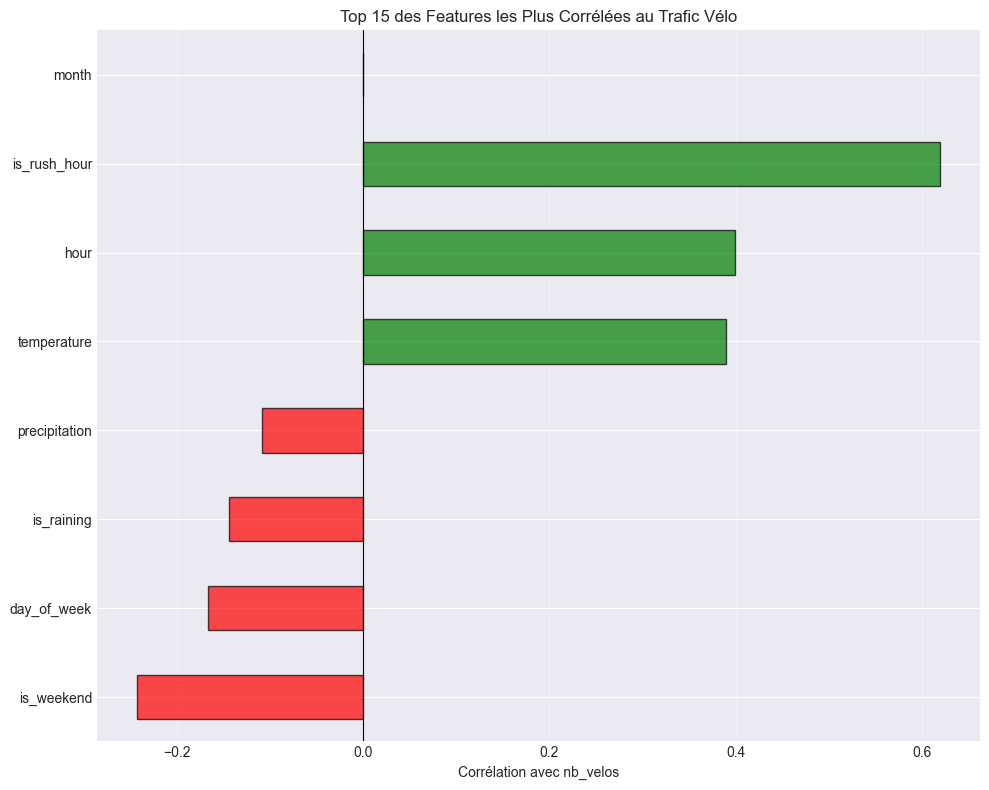


Les features en VERT augmentent le trafic
Les features en ROUGE diminuent le trafic


In [13]:
# Visualisation : Top 15 des features les plus corrélées
plt.figure(figsize=(10, 8))

# Prendre les 15 features les plus corrélées (en valeur absolue)
top_corr = correlations.drop('nb_velos').abs().sort_values(ascending=False).head(15)
top_features = correlations[top_corr.index].sort_values()

# Barplot horizontal
colors = ['red' if x < 0 else 'green' for x in top_features.values]
top_features.plot(kind='barh', color=colors, edgecolor='black', alpha=0.7)
plt.xlabel('Corrélation avec nb_velos')
plt.title('Top 15 des Features les Plus Corrélées au Trafic Vélo')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nLes features en VERT augmentent le trafic")
print("Les features en ROUGE diminuent le trafic")

---
## 3.6 Statistiques Descriptives Finales

In [14]:
print("Statistiques descriptives du dataset final :")
print("="*80)
df_encoded.describe()

Statistiques descriptives du dataset final :


,nb_velos,temperature,precipitation,hour,day_of_week,is_weekend,month,is_rush_hour,is_raining
count,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.0,696.000000,696.000000
mean,10072.785920,12.710508,1.472989,11.500000,3.034483,0.275862,4.0,0.250000,0.166667
std,9024.364654,5.416150,7.217500,6.927165,1.975087,0.447269,0.0,0.433324,0.372946
min,225.000000,0.294408,0.000000,0.000000,0.000000,0.000000,4.0,0.000000,0.000000
25%,2667.000000,9.965616,0.000000,5.750000,1.000000,0.000000,4.0,0.000000,0.000000
50%,8552.000000,13.458946,0.000000,11.500000,3.000000,0.000000,4.0,0.000000,0.000000
75%,13954.500000,16.488281,0.000000,17.250000,5.000000,1.000000,4.0,0.250000,0.000000
max,44073.000000,22.662829,114.300000,23.000000,6.000000,1.000000,4.0,1.000000,1.000000


In [15]:
# Vérifier qu'il n'y a pas de valeurs manquantes
print("Vérification des valeurs manquantes :")
print("="*80)
missing = df_encoded.isnull().sum()
if missing.sum() == 0:
    print("Aucune valeur manquante! Dataset prêt pour le ML.")
else:
    print("Valeurs manquantes détectées :")
    print(missing[missing > 0])

Vérification des valeurs manquantes :
Aucune valeur manquante! Dataset prêt pour le ML.


---
## 3.7 Sauvegarde du Dataset Final

In [16]:
# Sauvegarder le dataset avec toutes les features
output_path = '../CSVs/data_with_features.csv'
df_encoded.to_csv(output_path, index=False, sep=';')

print("Dataset avec features sauvegardé!")
print("="*80)
print(f"Fichier : {output_path}")
print(f"Dimensions : {df_encoded.shape[0]:,} lignes x {df_encoded.shape[1]} colonnes")
print(f"Période : {df_encoded['timestamp'].min()} → {df_encoded['timestamp'].max()}")
print("\nPrêt pour l'étape 4 : Modélisation (Machine Learning)!")

Dataset avec features sauvegardé!
Fichier : ../CSVs/data_with_features.csv
Dimensions : 696 lignes x 24 colonnes
Période : 2022-04-01 00:00:00+02:00 → 2022-04-29 23:00:00+02:00

Prêt pour l'étape 4 : Modélisation (Machine Learning)!


---
## 3.8 Résumé de l'Étape 3

### Features Temporelles Créées :
1. `hour` : Heure de la journée (0-23)
2. `day_of_week` : Jour de la semaine (0-6)
3. `day_name` : Nom du jour (encodé en one-hot)
4. `is_weekend` : Weekend ou non (0/1)
5. `month` : Mois (4 pour avril)
6. `is_rush_hour` : Heure de pointe (0/1)

### Features Météo Enrichies :
1. `is_raining` : Il pleut ou non (0/1)
2. `rain_intensity` : Intensité pluie (encodé en one-hot)
3. `temp_category` : Catégorie température (encodé en one-hot)

### Encodage One-Hot :
- Variables catégorielles transformées en colonnes binaires
- Dataset prêt pour les algorithmes de ML

### Dataset Final :
- **Lignes** : 696 (29 jours × 24h)
- **Colonnes** : ~25-30 colonnes (selon l'encodage)
- **Fichier** : `data_with_features.csv`

### Prochaine Étape :
**Étape 4 : Modélisation**
- Train/Test Split
- Régression Linéaire (baseline)
- Random Forest (modèle avancé)
- Évaluation des performances

---
**Étape 3 terminée !**